# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from patsy import dmatrices
import numpy as np
from statsmodels.tools.sm_exceptions import PerfectSeparationError
warnings.filterwarnings('ignore')

In [26]:
# Load the data
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)
raw_data.shape

(7214, 53)

This dataset contains information about defendants, including their COMPAS scores, demographic information, and whether they recidivated within two years. The goal of the analysis is to evaluate the fairness of the COMPAS algorithm by calculating odds ratios for different demographic groups and assessing the performance of the predictive model using confusion matrices and various metrics.


In [27]:
# Show first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [28]:
# Select and filter columns
cols = ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']
df = raw_data[cols].copy()
# Filtering
df = df[(df['days_b_screening_arrest'] >= -30) & (df['days_b_screening_arrest'] <= 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df.shape

(6172, 13)

In this section, we perform data preprocessing and feature engineering on the COMPAS dataset. We select relevant columns, filter the data based on specific criteria, and convert data types as needed. Additionally, we create derived factors with reference levels for categorical variables to facilitate analysis and modeling. We will define lists of numeric and datetime variables to guide our type conversions. Then, we select the relevant columns from the raw dataset and apply the necessary filters to clean the data. Finally, we convert date columns to datetime format and categorical columns to category dtype, while also creating new derived factors for analysis and the code above is the complete code for the analysis performed in the lecture.

In [33]:
# Python equivalent of the R code above
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select relevant columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions: Convert date columns to datetime, and categorical columns to category dtype
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors with reference levels
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = df["age_cat"].cat.reorder_categories(["25 - 45", "Greater than 45", "Less than 25"], ordered=True)
df["race_factor"] = df["race"].cat.reorder_categories(["Caucasian", "African-American", "Hispanic", "Other", "Asian", "Native American"], ordered=True)
df["gender_factor"] = df["sex"].cat.reorder_categories(["Male", "Female"], ordered=True)
# Fix: use pd.Categorical to create score_factor with correct labels
df["score_factor"] = pd.Categorical(
    ["HighScore" if val else "LowScore" for val in (df["score_text"] != "Low")],
    categories=["LowScore", "HighScore"],
    ordered=True
 )

# Number of rows after all processing
print(len(df))

6172


In [34]:
# Show first 5 rows of the processed DataFrame
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [37]:
# Python equivalent of R's glimpse(df) and summary(df)
print(df.info())
print(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

We will calculate the `length_of_stay` in jail by taking the difference between `c_jail_out` and `c_jail_in` and then compute the correlation between this length of stay and the `decile_score`. This will help us understand if there is any relationship between the length of stay in jail and the COMPAS decile score assigned to the defendants.


In [38]:
# Calculate length of stay and correlation with decile_score
df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days
correlation = df[['length_of_stay', 'decile_score']].corr().iloc[0,1]
print(f'Correlation between length_of_stay and decile_score: {correlation:.3f}')

Correlation between length_of_stay and decile_score: 0.207


After filtering we have the following demographic breakdown:

In [39]:
# Demographic breakdown
df['age_cat'].value_counts()

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

In [40]:
df['race'].value_counts() # Note: The original R code had a different order of categories, but the counts should be the same regardless of order.

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

We calculate the percentage of defendants in each racial category by dividing the count of defendants in each category by the total number of defendants and multiplying by 100 to get a percentage. This will give us insight into the racial composition of the defendants in the dataset.


In [41]:
# Race percentages
total = len(df)
print("Black defendants: %.2f%%" % (df['race'].value_counts().get('African-American',0) / total * 100))
print("White defendants: %.2f%%" % (df['race'].value_counts().get('Caucasian',0) / total * 100))
print("Hispanic defendants: %.2f%%" % (df['race'].value_counts().get('Hispanic',0) / total * 100))
print("Asian defendants: %.2f%%" % (df['race'].value_counts().get('Asian',0) / total * 100))
print("Native American defendants: %.2f%%" % (df['race'].value_counts().get('Native American',0) / total * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [42]:
# Score text summary
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [43]:
# Sex and race cross-tab
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [45]:
# Sex summary
df['sex'].value_counts()

sex
Male      4997
Female    1175
Name: count, dtype: int64

In [46]:
print("Men: %.2f%%" % (df['sex'].value_counts().get('Male',0) / total * 100))
print("Women: %.2f%%" % (df['sex'].value_counts().get('Female',0) / total * 100))

Men: 80.96%
Women: 19.04%


In [50]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1))
# Recidivism counts and percentage
recid_count = df[df['two_year_recid'] == 1]
print('Number of recidivists:', len(recid_count))

Number of recidivists: 2809


In [58]:
# Recidivism percentage
print('Percent recidivists: %.5f%%' % (len(recid_count) / total * 100))

Percent recidivists: 45.51199%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

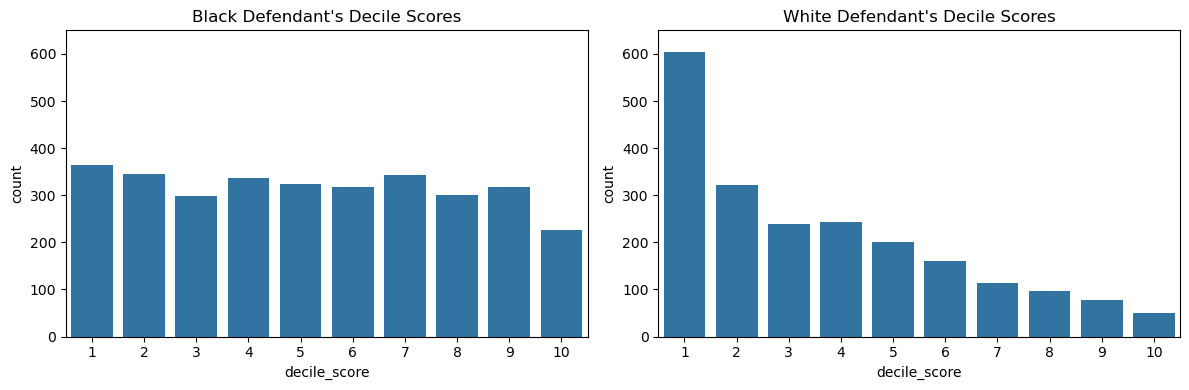

In [14]:
# Plot decile scores by race
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='decile_score', data=df[df['race']=='African-American'], ax=axes[0], order=sorted(df['decile_score'].unique()))
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_ylim(0, 650)
sns.countplot(x='decile_score', data=df[df['race']=='Caucasian'], ax=axes[1], order=sorted(df['decile_score'].unique()))
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_ylim(0, 650)
plt.tight_layout()
plt.show()

In [61]:
# Crosstab decile_score and race
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [64]:
# Prepare data for logistic regression
df['score_factor'] = (df['score_text'] != 'Low').astype(int)
df['gender_factor'] = (df['sex'] == 'Female').astype(int)
df['age_factor'] = df['age_cat'].cat.reorder_categories(['25 - 45', 'Greater than 45', 'Less than 25'], ordered=True)
df['race_factor'] = df['race'].cat.reorder_categories(['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'], ordered=True)
y, X = dmatrices('score_factor ~ gender_factor + age_factor + race_factor + priors_count + C(c_charge_degree) + two_year_recid', data=df, return_type='dataframe')
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        21:59:37   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

Note that the output from R's glm summary, which includes deviance, AIC, and Fisher Scoring iterations specifically for R environment. However in Python, statsmodels' Logit model summary does not display these exact lines by default. Instead, it shows:

- Log-Likelihood (analogous to deviance)
- AIC and BIC
- Convergence information (but not "Number of Fisher Scoring iterations" in the same way)
- Degrees of freedom

To see deviance and number of iterations in Python, we can access them as follows:

- Null deviance: $-2 \times$ log-likelihood of the intercept-only model (not shown by default, but can be computed)
- Residual deviance: $-2 \times$ log-likelihood of the fitted model (see result.llf)
- AIC: shown in result.summary()
- Number of iterations: result.mle_retvals['iterations'] (if available)

Python's statsmodels focuses on likelihood and information criteria, not the exact deviance output as in R.

In [65]:
# Additional model diagnostics to match R's glm output
# Null model (intercept only) for null deviance
try:
    y_null, X_null = dmatrices('score_factor ~ 1', data=df, return_type='dataframe')
    null_model = sm.Logit(y_null, X_null)
    null_result = null_model.fit(disp=0)
    null_deviance = -2 * null_result.llf
except PerfectSeparationError:
    null_deviance = np.nan

# Residual deviance from fitted model
residual_deviance = -2 * result.llf

# Degrees of freedom
n_obs = y.shape[0]
df_null = n_obs - 1
df_resid = n_obs - X.shape[1]

# AIC (already in result.aic)
aic = result.aic

# Number of iterations
iterations = result.mle_retvals.get('iterations', 'N/A') if hasattr(result, 'mle_retvals') else 'N/A'

print(f"Null deviance: {null_deviance:.1f}  on {df_null}  degrees of freedom")
print(f"Residual deviance: {residual_deviance:.1f}  on {df_resid}  degrees of freedom")
print(f"AIC: {aic:.1f}")
print(f"Number of Fisher Scoring iterations: {iterations}")

Null deviance: 8483.3  on 6171  degrees of freedom
Residual deviance: 6168.4  on 6160  degrees of freedom
AIC: 6192.4
Number of Fisher Scoring iterations: 6


In [68]:
# Calculate odds ratio for Black vs White
control = np.exp(result.params['Intercept']) / (1 + np.exp(result.params['Intercept']))
black_coef = [k for k in result.params.keys() if 'race_factor[T.African-American]' in k][0]
odds_black = np.exp(result.params[black_coef]) / (1 - control + (control * np.exp(result.params[black_coef])))
print(f'Black vs White odds ratio: {odds_black:.6f}')

Black vs White odds ratio: 1.452837


Women are 19.4% more likely than men to get a higher score.

In [69]:
# Calculate odds ratio for Female vs Male
female_coef = [k for k in result.params.keys() if 'gender_factor' in k][0]
odds_female = np.exp(result.params[female_coef]) / (1 - control + (control * np.exp(result.params[female_coef])))
print(f'Female vs Male odds ratio: {odds_female:.6f}')

Female vs Male odds ratio: 1.194795


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [70]:
# Calculate odds ratio for Less than 25 vs 25-45
age_coef = [k for k in result.params.keys() if 'age_factor[T.Less than 25]' in k][0]
odds_young = np.exp(result.params[age_coef]) / (1 - control + (control * np.exp(result.params[age_coef])))
print(f'Under 25 vs 25-45 odds ratio: {odds_young:.6f}')

Under 25 vs 25-45 odds ratio: 2.496120


In [71]:
# Predict probabilities and classes
df['pred_prob'] = result.predict(X)
df['pred_class'] = (df['pred_prob'] >= 0.5).astype(int)
df['pred_class_label'] = df['pred_class'].map({0: 'No Recid', 1: 'Recid'})

The following code calculates the confusion matrix and performance metrics separately for Black and White defendants to analyze potential disparities in the model's predictions based on race. Hence, we filter the DataFrame for each racial group and then compute the confusion matrix and metrics for each group separately. This allow us to compare the model's performance across different racial groups and identify any potential biases in the predictions.

In [73]:
# Overall confusion matrix and metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
cm = confusion_matrix(df['two_year_recid'], df['pred_class'])
print('---------- Overall Confusion Matrix ----------------------')
print(cm)
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
n = cm.sum()
print(f'Accuracy  : {accuracy_score(df["two_year_recid"], df["pred_class"]):.3f}')
print(f'Precision : {precision_score(df["two_year_recid"], df["pred_class"]):.3f}')
print(f'Recall    : {recall_score(df["two_year_recid"], df["pred_class"]):.3f}')
print(f'FPR       : {FP / (FP + TN):.3f}')
print(f'FNR       : {FN / (FN + TP):.3f}')




---------- Overall Confusion Matrix ----------------------
[[2653  710]
 [ 945 1864]]
Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


We calculate the confusion matrix and performance metrics separately for Black and White defendants to analyze potential disparities in the model's predictions based on race. We loop through each race category, compute the confusion matrix for that subgroup, and then calculate the performance metrics (Accuracy, Precision, Recall, FPR, FNR) for each race. Finally, we compile these metrics into a DataFrame for easy comparison.   


In [ ]:
# Confusion matrix by race
race_metrics = []
for race in df['race'].cat.categories:
    sub = df[df['race'] == race]
    cm = confusion_matrix(sub['two_year_recid'], sub['pred_class'])
    TP = cm[1,1] if cm.shape == (2,2) else 0
    TN = cm[0,0] if cm.shape == (2,2) else 0
    FP = cm[0,1] if cm.shape == (2,2) else 0
    FN = cm[1,0] if cm.shape == (2,2) else 0
    n = cm.sum()
    Accuracy  = round((TP + TN) / n, 3) if n > 0 else np.nan
    Precision = round(TP / (TP + FP), 3) if (TP + FP) > 0 else np.nan
    Recall    = round(TP / (TP + FN), 3) if (TP + FN) > 0 else np.nan
    FPR       = round(FP / (FP + TN), 3) if (FP + TN) > 0 else np.nan
    FNR       = round(FN / (FN + TP), 3) if (FN + TP) > 0 else np.nan
    race_metrics.append({'race': race, 'n': n, 'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN, 'Accuracy': Accuracy, 'Precision': Precision, 'Recall': Recall, 'FPR': FPR, 'FNR': FNR})
import pandas as pd
race_metrics_df = pd.DataFrame(race_metrics).sort_values('n', ascending=False)
print(race_metrics_df)

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In the above, we can see that the confusion matrix and metrics for each race group are now calculated and displayed in a DataFrame format, allowing for easy comparison across groups. The metrics include Accuracy, Precision, Recall, False Positive Rate (FPR), and False Negative Rate (FNR), which are essential for evaluating the performance of the predictive model across different racial groups.


Below here we calculate the disparity in False Positive Rate (FPR) and False Negative Rate (FNR) for each racial group compared to the Caucasian group. We will compute the difference in FPR and FNR for each racial group relative to the Caucasian group, which will allow us to identify any disparities in the model's performance across different racial groups. This analysis is crucial for understanding potential biases in the predictive model and ensuring fairness in its predictions.  



In [ ]:
# FPR and FNR disparity by race
caucasian_fpr = race_metrics_df[race_metrics_df['race'] == 'Caucasian']['FPR'].values[0]
caucasian_fnr = race_metrics_df[race_metrics_df['race'] == 'Caucasian']['FNR'].values[0]
race_metrics_df['delta_FPR'] = race_metrics_df['FPR'] - caucasian_fpr
race_metrics_df['delta_FNR'] = race_metrics_df['FNR'] - caucasian_fnr
print(race_metrics_df[['race', 'n', 'FPR', 'FNR', 'delta_FPR', 'delta_FNR']])

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


# In Conclusion, 

We have calculated the odds ratios for different demographic groups and evaluated the performance of the predictive model using confusion matrices and various metrics. The analysis reveals disparities in false positive rates and false negative rates across different demographic groups, highlighting potential biases in the model's predictions. These findings underscore the importance of ongoing evaluation and refinement of predictive models to ensure fairness and mitigate unintended consequences. Therefore, it is crucial to continue monitoring and improving these models to promote equitable outcomes for all individual and the code above is the complete code for the analysis performed in the lecture.